In [25]:
import pandas as pd
df = pd.read_csv(
    r"C:\Users\jeeva\Documents\Hierarchical_Clustering\OnlineRetail.csv",
    encoding="latin1"
)

In [26]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


In [38]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [28]:
df = df.dropna(subset=['CustomerID'])


In [29]:
df['Description'] = df['Description'].fillna("Unknown")


In [40]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['UnitPrice'] = df['UnitPrice'].fillna(df['UnitPrice'].median())


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [31]:
X = df.select_dtypes(include=['float64', 'int64'])


In [42]:
customer_df = df.groupby('CustomerID').agg({
    'Quantity': 'sum',        # total items bought
    'UnitPrice': 'mean'       # average spending
}).reset_index()

print(customer_df.shape)



(4372, 3)


In [43]:
X = customer_df[['Quantity', 'UnitPrice']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


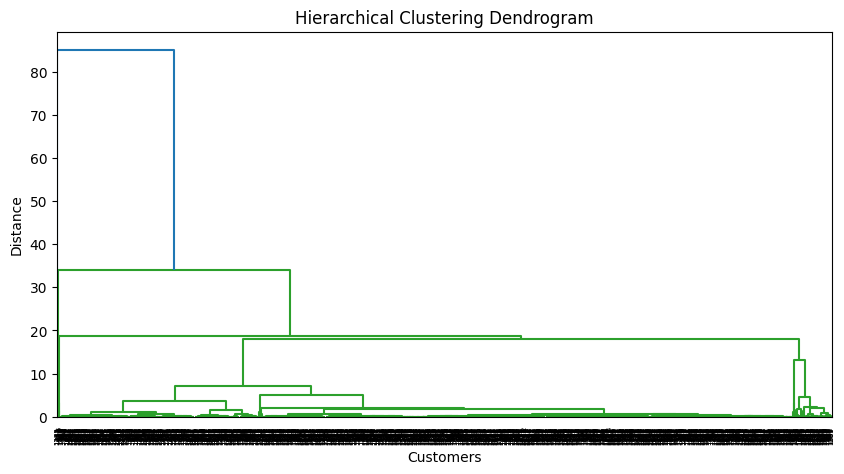

In [44]:
# sample max 2000 customers for dendrogram
sample_idx = np.random.choice(X_scaled.shape[0], 2000, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()


In [45]:
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

labels = hc.fit_predict(X_scaled)
customer_df['Cluster'] = labels

print(customer_df.head())


   CustomerID  Quantity  UnitPrice  Cluster
0     12346.0         0   1.040000        2
1     12347.0      2458   2.644011        2
2     12348.0      2341   5.764839        2
3     12349.0       631   8.289041        2
4     12350.0       197   3.841176        2


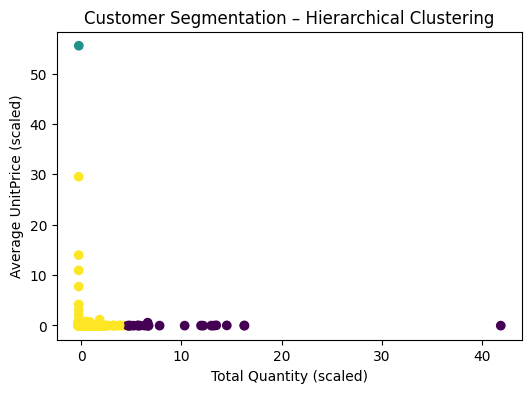

In [46]:
plt.figure(figsize=(6, 4))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels
)
plt.xlabel("Total Quantity (scaled)")
plt.ylabel("Average UnitPrice (scaled)")
plt.title("Customer Segmentation – Hierarchical Clustering")
plt.show()


In [48]:
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("labels.pkl", "wb") as f:
    pickle.dump(labels, f)

with open("customer_df.pkl", "wb") as f:
    pickle.dump(customer_df, f)

print("Pickle files saved: scaler.pkl, labels.pkl, customer_df.pkl")

Pickle files saved: scaler.pkl, labels.pkl, customer_df.pkl
